<a href="https://colab.research.google.com/github/tinadams/carisurg-portfolio/blob/feat%2Fweek-0-refactor/Day2_CleanFio2Column_GroupAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 0 Day 2: Cleaning the FiO2 Column

**Project:** Mercer General Hospital Emergency Department Triage Dataset  
**Authors:** Justine Alew, Imani Zakuri, Tessa Adams, Dillon Francis, Azaria DaSilva  
**Date:** 21 May 2026  

## Objective

This notebook prepares the synthetic Mercer General ED dataset for FiO2 cleaning.

## Environment Setup

This step imports the required Python libraries, connects Google Drive, and checks the Python version.

In [37]:
# Environment setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

# Always confirm Python version first
import sys
print(f"Python version: {sys.version}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


## Load Dataset and Apply Previous Cleaning

This step loads the Mercer General ED dataset and reapplies the gender cleaning from Day 1 before continuing with Day 2 cleaning.

In [38]:
# Re-loading dataset from assignment 1
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# Re-applying gender cleaning from assignment 1
gender_map = {'Male': 1,'MALE': 1, '1': 1, 'Female' : 0, 'FEMALE' : 0, '0' : 0 }
df['Gender'] = df['Gender'].map(gender_map)

## Data Exploration

This section previews the first and last 5 rows of the dataset, checks column types, reviews summary statistics, and confirms the dataset size before cleaning.

In [39]:
# Printing first five rows
print("First 5 rows in dataset")
print(df.head())

First 5 rows in dataset
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0


In [40]:
# Printing last five rows
print("Last 5 rows in dataset")
print(df.tail())

Last 5 rows in dataset
        ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR  Fio2
2200  2380   65       1  14.0  170   50.0   90.00   65.0  37.0  22.0  21.0
2201  2381   84       0  15.0  180  120.0  140.00   85.0  36.1  18.0  21.0
2202  2382   78       0  15.0  132   78.0   96.00  100.0  37.9  16.0  21.0
2203  2383   65       1  15.0  140   80.0  100.00   85.0  36.4  16.0  21.0
2204  2384   78       0  15.0  145   90.0  108.33   75.0  37.6  20.0  21.0


In [41]:
# Printing information on dataset
print("Column types and non-null count")
print(df.info())

Column types and non-null count
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   int64  
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 189.6+ KB
None


In [42]:
# Printing statistic on dataset numeric columns
print("Statistics for numeric columns")
print(df.describe())

Statistics for numeric columns
                ID          Age       Gender          DBP          MAP  \
count  2205.000000  2205.000000  2205.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478     0.533333    77.479615    93.912277   
std     677.167364    18.485363     0.499001    16.713289    19.006296   
min       1.000000    18.000000     0.000000    30.000000    39.330000   
25%     577.000000    50.000000     0.000000    70.000000    82.500000   
50%    1135.000000    64.000000     1.000000    78.000000    93.330000   
75%    1703.000000    77.000000     1.000000    87.000000   103.330000   
max    2384.000000    98.000000     1.000000   173.000000   185.000000   

                RR         Fio2  
count  2183.000000  2183.000000  
mean     20.262254    25.019698  
std       5.742333    10.144288  
min      12.000000    21.000000  
25%      17.000000    21.000000  
50%      18.000000    21.000000  
75%      21.000000    21.000000  
max      50.000000   100.00000

In [43]:
# Printing size of dataset
print("Size of dataset:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Size of dataset:
Rows: 2205, Columns: 11


## Clean GCS Column

This section converts `GCS` values to numeric format, checks for invalid values, visualises the distribution, and fills missing values using the median.

GCS dtype: object
Unique GCS values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']




After conversion:
  dtype: float64
  NaN count: 44
  Range: 3.0 to 15.0




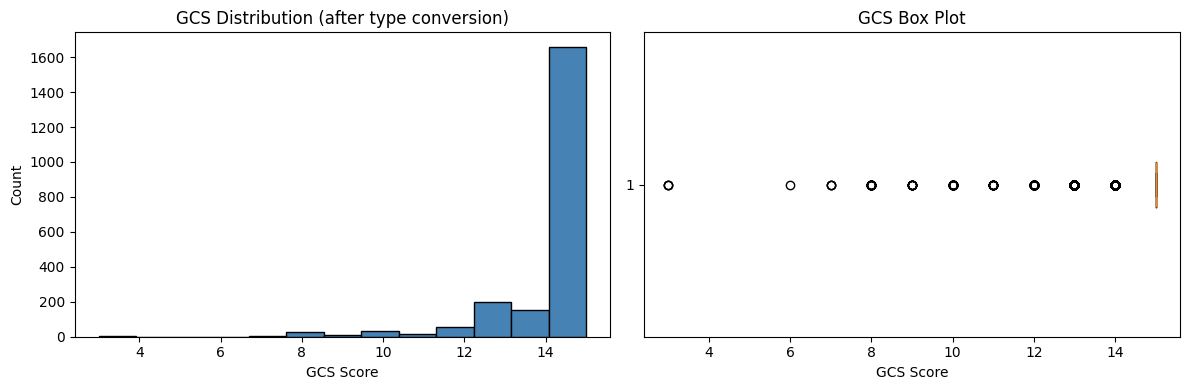

Plot saved as gcs_distribution.png


GCS values outside valid range (3–15): 0 rows
Empty DataFrame
Columns: [ID, GCS]
Index: []


NaN count after range filter: 44


GCS median (before imputation): 15.0
GCS after imputation:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
Remaining NaNs: 0


In [44]:
# GCS is currently stored as a string (object type)
print("GCS dtype:", df['GCS'].dtype)
print("Unique GCS values:", df['GCS'].unique())
print("\n")

# pd.to_numeric() with errors='coerce' converts numbers and turns
# everything non-numeric (like 'error') into NaN
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
print("\n")

print("After conversion:")
print(f"  dtype: {df['GCS'].dtype}")
print(f"  NaN count: {df['GCS'].isnull().sum()}")
print(f"  Range: {df['GCS'].min()} to {df['GCS'].max()}")
print("\n")

# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['GCS'].dropna(), bins=13, edgecolor='black', color='steelblue')
axes[0].set_xlabel('GCS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('GCS Distribution (after type conversion)')

axes[1].boxplot(df['GCS'].dropna(), vert=False)
axes[1].set_xlabel('GCS Score')
axes[1].set_title('GCS Box Plot')

plt.tight_layout()
plt.savefig('gcs_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as gcs_distribution.png")
print("\n")

# Step 2: Flag physiologically impossible values
# GCS valid range: 3–15
invalid_gcs = df[(df['GCS'] < 3) | (df['GCS'] > 15)]
print(f"GCS values outside valid range (3–15): {len(invalid_gcs)} rows")
print(invalid_gcs[['ID', 'GCS']].head(10))
print("\n")

# Step 3: Replace invalid values with NaN
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
print(f"NaN count after range filter: {df['GCS'].isnull().sum()}")
print("\n")

# Compute the median and use it to fill NaN values
gcs_median = df['GCS'].median()
print(f"GCS median (before imputation): {gcs_median}")

df['GCS'] = df['GCS'].fillna(gcs_median)

print(f"GCS after imputation:")
print(df['GCS'].describe())
print(f"Remaining NaNs: {df['GCS'].isnull().sum()}")



## Clean SBP Column

This section cleans systolic blood pressure (`SBP`) by converting values to numeric format, removing clinically invalid values, and filling missing values using the median.

In [45]:
# SBP = Systolic Blood Pressure. Valid range: 50–250 mmHg.
# Extremely low SBP (<70) = shock risk. Extremely high (>200) = hypertensive crisis.

print("SBP unique values (sample):", df['SBP'].unique()[:15])
print("SBP dtype:", df['SBP'].dtype)
print('\n')

# 1. Convert to numeric — non-numeric entries become NaN
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
print("After type conversion:")
print(df['SBP'].describe())
print('\n')

# 2. Identify out-of-range values
invalid_sbp = df[(df['SBP'] < 50) | (df['SBP'] > 250)]
print(f"Out-of-range SBP rows: {len(invalid_sbp)}")
print(invalid_sbp[['ID', 'SBP']].head())
print('\n')

# 3. Replace out-of-range with NaN, then impute with median
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
sbp_median = df['SBP'].median()
df['SBP'] = df['SBP'].fillna(sbp_median)

print(f"SBP after cleaning: min={df['SBP'].min()}, max={df['SBP'].max()}, NaNs={df['SBP'].isnull().sum()}")
print('\n')



SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


After type conversion:
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64


Out-of-range SBP rows: 44
      ID    SBP
29    32   30.0
111  123  500.0
168  183  500.0
231  247   30.0
275  291  500.0


SBP after cleaning: min=55.0, max=250.0, NaNs=0




## Clean Temperature Column

This section standardises temperature values into Celsius, removes clinically invalid values, and fills missing values using the median.

In [46]:
# First, look at the raw values
print("Temp unique values (sample):")
print(df['Temp'].unique()[:20])
print('\n')

# Write a function to standardise everything to Celsius
def to_celsius(val):
    """Convert temperature value to Celsius float.
    Handles: plain numbers, strings ending in 'C', strings ending in 'F'.
    Returns NaN for anything unrecognisable.
    """
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])          # remove 'C', convert
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)               # assume Celsius already
    except ValueError:
        return np.nan                           # anything else -> NaN

df['Temp'] = df['Temp'].apply(to_celsius)

print("After standardisation:")
print(df['Temp'].describe())

print('\n')

# Apply range filter: valid body temperature 32–43°C
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan

# Impute with median
temp_median = round(df['Temp'].median(), 1)
df['Temp'] = df['Temp'].fillna(temp_median)

print(f"Temp after cleaning: min={df['Temp'].min():.1f}, max={df['Temp'].max():.1f}, NaNs={df['Temp'].isnull().sum()}")
print('\n')

Temp unique values (sample):
['36.8' '37.0' '36.5' '39.0' '37.3' '36.7' '37.8' '38.5' '38.0' '37.6'
 '38.2' '37C' '36.2' '37.2' '37.5' nan '36.9' '39.6' '37.4' '50']


After standardisation:
count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


Temp after cleaning: min=35.0, max=41.7, NaNs=0




## Inspect FiO2 Column

This section checks the `FiO2` data type, unique values, missing values, and range before cleaning.

In [47]:
# Fio2 is currently stored as a float
print("Fio2 dtype:", df['Fio2'].dtype)
print("Unique Fi02 values:", df['Fio2'].unique())

Fio2 dtype: float64
Unique Fi02 values: [ 21. 100.  40.  nan  60.  95.  80.  70.]


In [48]:
# Determining the NaN count and Range
print(f"NaN count: {df['Fio2'].isnull().sum()}")
print(f"Range: {df['Fio2'].min()} to {df['Fio2'].max()}")


NaN count: 22
Range: 21.0 to 100.0


## Set FiO2 Cleaning Rules

This step defines the `FiO2` column name and the valid clinical range of `21%` to `100%`.

In [49]:
# Fio2 Column Information
COLUMN = 'Fio2'
VALID_MIN = 21
VALID_MAX = 100
print(f"Cleaning {COLUMN}")

Cleaning Fio2


## Visualise FiO2 Before Cleaning

This step creates a histogram and box plot to inspect the FiO2 distribution and identify possible outliers before cleaning.

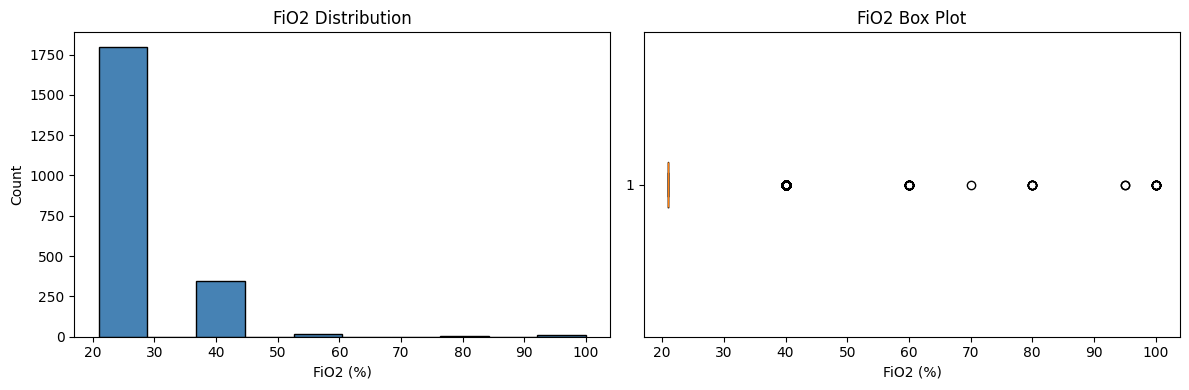

Plot saved as fio2_distribution.png


In [50]:
# Step 1: Visualise BEFORE removing anything
# to idenitfy data skew and outliers

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['Fio2'].dropna(), bins=10, edgecolor='black', color='steelblue')
axes[0].set_xlabel('FiO2 (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('FiO2 Distribution')

# Box plot
axes[1].boxplot(df['Fio2'].dropna(), vert=False)
axes[1].set_xlabel('FiO2 (%)')
axes[1].set_title('FiO2 Box Plot')

plt.tight_layout()
plt.savefig('fio2_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plot saved as fio2_distribution.png")

## Identify Invalid FiO2 Values

This step checks for FiO2 values outside the valid clinical range of `21%` to `100%`.

In [51]:
# Step 2: Determine if there are invalid values in the Fio2 column
# Innacurate or clinically impossible data can cause inaccurate analysis
invalid_fio2 = df[(df['Fio2'] < VALID_MIN) | df['Fio2'] > VALID_MAX]
print(f"Fio2 values outside valid range (21-100): {len(invalid_fio2)} rows")
print(invalid_fio2[['ID', 'Fio2']].head(10))

Fio2 values outside valid range (21-100): 0 rows
Empty DataFrame
Columns: [ID, Fio2]
Index: []


## Replace Invalid FiO2 Values

This step replaces FiO2 values outside the valid range with missing values so they can be handled consistently.

In [52]:
# Step 3: Changing the invalid values to NaN
# Inavlid values are changed to NaN to maintain consistency across the dataset
df.loc[(df['Fio2'] < VALID_MIN) | (df['Fio2'] > VALID_MAX), 'Fio2'] = np.nan
print(f"NaN count after range filter: {df['Fio2'].isnull().sum()}")

NaN count after range filter: 22


## Fill Missing FiO2 Values

This step fills missing FiO2 values using the mode, which represents the most common oxygen setting in the dataset.

In [53]:
# Step 4: Compute the mode and use it to fill NaN values
#
# Mode imputation is used because FiO2 values occur at standard
# clinical oxygen settings (e.g. 21%, 40%, 60%, 100%).
# Using the mode preserves the most commonly observed treatment level.
#
#Based on output, only one mode returned so to print the mode without its index
Fio2_mode = df['Fio2'].mode()[0]
print(f"Fio2 mode (before imputation):{Fio2_mode}")

df['Fio2'] = df['Fio2'].fillna(Fio2_mode)

print(f"Fio2 after imputation:")
print(df['Fio2'].describe())
print(f"\nUpdated NaN count: {df['Fio2'].isnull().sum()}")




Fio2 mode (before imputation):21.0
Fio2 after imputation:
count    2205.000000
mean       24.979592
std        10.101438
min        21.000000
25%        21.000000
50%        21.000000
75%        21.000000
max       100.000000
Name: Fio2, dtype: float64

Updated NaN count: 0
